In [1]:
import duckdb 

with open ("sql/load_sakila.sql", "r") as sql_file: # r instead of read
    loading_script = sql_file.read()

type(loading_script)

str

In [2]:
from pathlib import Path 
duckdb_path = "data/sakila.duckdb"
Path(duckdb_path).unlink(missing_ok=True)

with duckdb.connect(duckdb_path) as conn, open("sql/load_sakila.sql") as ingest_script:
    conn.sql(ingest_script.read())

    description = conn.sql("DESC;").df()
    films = conn.sql("FROM film;").df()

films.head(3)

,film_id,title,description,release_year,language_id,original_language_id,rental_duration,rental_rate,length,replacement_cost,rating,special_features,last_update
0,1,ACADEMY DINOSAUR,A Epic Drama of a Feminist And a Mad Scientist...,2006,1,<NA>,6,0.99,86,20.99,PG,"Deleted Scenes,Behind the Scenes",2021-03-06 15:52:00
1,2,ACE GOLDFINGER,A Astounding Epistle of a Database Administrat...,2006,1,<NA>,3,4.99,48,12.99,G,"Trailers,Deleted Scenes",2021-03-06 15:52:00
2,3,ADAPTATION HOLES,A Astounding Reflection of a Lumberjack And a ...,2006,1,<NA>,7,2.99,50,18.99,NC-17,"Trailers,Deleted Scenes",2021-03-06 15:52:00


In [4]:


films.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   film_id               1000 non-null   int64         
 1   title                 1000 non-null   object        
 2   description           1000 non-null   object        
 3   release_year          1000 non-null   object        
 4   language_id           1000 non-null   int64         
 5   original_language_id  0 non-null      Int64         
 6   rental_duration       1000 non-null   int64         
 7   rental_rate           1000 non-null   float64       
 8   length                1000 non-null   int64         
 9   replacement_cost      1000 non-null   float64       
 10  rating                1000 non-null   object        
 11  special_features      1000 non-null   object        
 12  last_update           1000 non-null   datetime64[us]
dtypes: Int64(1), dateti

In [5]:
films.columns

Index(['film_id', 'title', 'description', 'release_year', 'language_id',
       'original_language_id', 'rental_duration', 'rental_rate', 'length',
       'replacement_cost', 'rating', 'special_features', 'last_update'],
      dtype='object')

In [6]:
duckdb.sql("from films;").df().head(3)

,film_id,title,description,release_year,language_id,original_language_id,rental_duration,rental_rate,length,replacement_cost,rating,special_features,last_update
0,1,ACADEMY DINOSAUR,A Epic Drama of a Feminist And a Mad Scientist...,2006,1,<NA>,6,0.99,86,20.99,PG,"Deleted Scenes,Behind the Scenes",2021-03-06 15:52:00
1,2,ACE GOLDFINGER,A Astounding Epistle of a Database Administrat...,2006,1,<NA>,3,4.99,48,12.99,G,"Trailers,Deleted Scenes",2021-03-06 15:52:00
2,3,ADAPTATION HOLES,A Astounding Reflection of a Lumberjack And a ...,2006,1,<NA>,7,2.99,50,18.99,NC-17,"Trailers,Deleted Scenes",2021-03-06 15:52:00


In [9]:


def query_sakila(query: str, duckdb_path = "data/sakila.duckdb"):
    with duckdb.connect(duckdb_path) as conn:
        df = conn.sql(query=query).df()

    return df

query_sakila("""
             SELECT 
                actor_id::INT AS actor_id,
                first_name || ' ' || last_name AS actor
             FROM actor;
             """)



,actor_id,actor
0,1,PENELOPE GUINESS
1,2,NICK WAHLBERG
2,3,ED CHASE
3,4,JENNIFER DAVIS
4,5,JOHNNY LOLLOBRIGIDA
...,...,...
195,196,BELA WALKEN
196,197,REESE WEST
197,198,MARY KEITEL
198,199,JULIA FAWCETT


In [11]:
films_joined = query_sakila("""
    SELECT 
        a.first_name || ' ' || a.last_name AS actor,
        f.title AS film_title,
        f.rating AS film_rating,
        c.name AS category,
        l.name AS language
    FROM film f
        LEFT JOIN film_actor fa ON f.film_id = fa.film_id
        LEFT JOIN actor a ON a.actor_id = fa.actor_id 
        LEFT JOIN film_category fc ON f.film_id = fc.film_id
        LEFT JOIN category c ON c.category_id = fc.category_id
        LEFT JOIN language l ON l.language_id = f.language_id
    ORDER BY 
        film_title
             ;
             """)

films_joined.head(5)

,actor,film_title,film_rating,category,language
0,PENELOPE GUINESS,ACADEMY DINOSAUR,PG,Documentary,English
1,WARREN NOLTE,ACADEMY DINOSAUR,PG,Documentary,English
2,JOHNNY CAGE,ACADEMY DINOSAUR,PG,Documentary,English
3,OPRAH KILMER,ACADEMY DINOSAUR,PG,Documentary,English
4,MENA TEMPLE,ACADEMY DINOSAUR,PG,Documentary,English


In [12]:
query_sakila("""
 SELECT
 film_title,
 COUNT(DISTINCT actor) AS actor_count
FROM films_joined
GROUP BY film_title
ORDER BY film_title;
""")

,film_title,actor_count
0,ACADEMY DINOSAUR,10
1,ACE GOLDFINGER,4
2,ADAPTATION HOLES,5
3,AFFAIR PREJUDICE,5
4,AFRICAN EGG,5
...,...,...
995,YOUNG LANGUAGE,5
996,YOUTH KICK,5
997,ZHIVAGO CORE,6
998,ZOOLANDER FICTION,5


In [17]:
films_joined.groupby("film_title")["actor"].nunique().sort_values(ascending=False)

film_title
LAMBS CINCINATTI     15
DRACULA CRYSTAL      13
CRAZY HOME           13
BOONDOCK BALLROOM    13
CHITTY LOCK          13
                     ..
MALTESE HOPE          1
BAKED CLEOPATRA       1
SLACKER LIAISONS      0
DRUMLINE CYCLONE      0
FLIGHT LIES           0
Name: actor, Length: 1000, dtype: int64

In [18]:


total_actors = query_sakila("""
    SELECT
     film_title,
     count (actor) AS total_actors,
    FROM films_joined
    GROUP BY film_title
    ORDER BY total_actors desc;
""")
total_actors.head(5)



,film_title,total_actors
0,LAMBS CINCINATTI,15
1,CHITTY LOCK,13
2,DRACULA CRYSTAL,13
3,BOONDOCK BALLROOM,13
4,MUMMY CREATURES,13


<Axes: xlabel='film_title'>

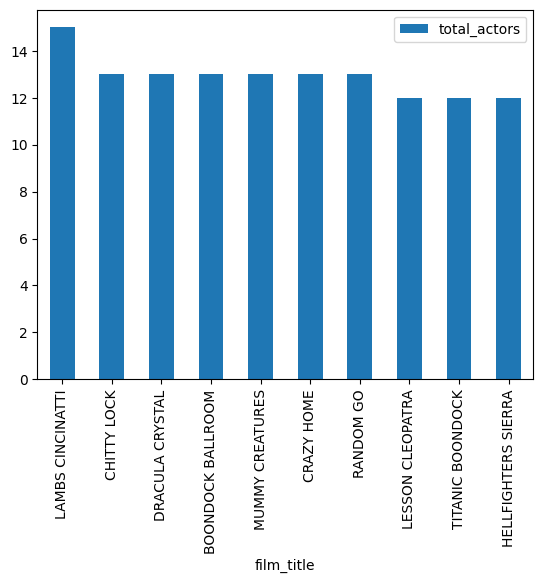

In [20]:
total_actors.head(10).plot(x = "film_title", y = "total_actors", kind="bar")